# Experimental setup

Set up for the experiment. This will load in the required packages, load in the data set, and load in the model. Then the experiment is run on the data set, saving the model weights and the results so they can be reloaded later. Below are the returned metrics.

## Metrics

- Overall performance in learned tasks: Usually average accuracy and average incremental accuracy, and confusion matrix
- Memory stability of old classes: uses forgetting measure (average forgetting of old tasks) and backward transfer (average influence of learning the k-th task on all old tasks)
- Learning plasticity of new classes: intransience measure (inability to learn a new task) and forward transfer (average influence of all old tasks on the current task)
- Resource (storage) and computational overheads (big O complexity), RAM usage.
- Discrepancy of task distribution

## Imports

In [1]:
# Load packages
import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets
from torchvision.transforms import transforms

# model and dataset factories
from models_classes.convnext import create_convnext
from dataset_classes.imagenette import ImagenetteContinual
from dataset_classes.cifar import CIFAR10Continual
from dataset_classes.cifar_small import CIFAR10SmallContinual

import numpy as np
import matplotlib.pyplot as plt

import os
import time

from collections import defaultdict

import requests

print(torch.__version__)
print(torch.cuda.is_available())
torch.set_default_device('cuda')

2.10.0+cu128
True


## Hyperparameters

In [ ]:
# Parameters

LOAD_FROM_FILE = False
FILE_LOAD_PATH = os.path.join(os.getcwd(), 'models', 'model_weights.pth')

TEST_INTERVAL = 'class' # Can be 'class', 'batch', or None.
TEST_EVERY_N = 100 # Number of batches between tests, only used if TEST_INTERVAL='batch'

# Debug: use a tiny CIFAR-10 subset for very fast script debugging runs
DEBUG_USE_SMALL_CIFAR = True
DEBUG_SAMPLES_PER_CLASS_TRAIN = 200
DEBUG_SAMPLES_PER_CLASS_TEST = 200
DEBUG_RANDOM_SEED = 42

# Router / MoE training controls (None = don't freeze router)
ROUTER_FREEZE_AFTER_BATCHES = None  # set to integer to stop training router after N batches

# Router balancing (equalize expert usage) — used only for MoE models
ROUTER_BALANCING = True
ROUTER_BALANCE_STRENGTH = 0.1

# Replay buffer (optional)
ENABLE_REPLAY = False
REPLAY_CAPACITY = 512 # increased from 64
REPLAY_POLICY = 'fifo'  # 'fifo' or 'random'
REPLAY_BATCH_SIZE = 4
REPLAY_WEIGHT = 5.0 # increased replay loss weight

# Pretraining options (optional balanced pretrain across classes)
ENABLE_PRETRAIN = False
PRETRAIN_SAMPLES_PER_CLASS = 0
PRETRAIN_REUSE = False  # if False, pretrain samples are removed from main stream
PRETRAIN_EPOCHS = 1

# Allow a shuffled (standard) training run for sanity checks
SHUFFLED_TRAIN = True

# Whether to compute measures that require training a separate reference/joint model
# (intranscience measure and forward transfer). Training a joint reference can be
# expensive; set to True only when you want the extra baselines computed.
COMPUTE_REFERENCE_BASELINES = False

REFERENCE_TRAIN_EPOCHS = 1 # epochs to train the joint/reference model when enabled
REFERENCE_BATCH_SIZE = 1 # batch size used for joint/reference training

# Build model using model factory (selectable)
# options: 'convnext', 'resnet', 'moe_vit'
MODEL_NAME = 'convnext'

# Define desired dataset (selectable)
# Instantiate dataset manager (Debug overrides to use small cifar)
# options: 'Imagenette', 'CIFAR10', 'CIFAR10Small'
DATASET_NAME = 'CIFAR10Small'

# Notify when complete? (Discord webhook URL in a file named hook.txt)
NOTIFICATIONS = False

## Model and Dataset setup

In [3]:
# Check for necessary output folders

folder_path = os.path.join(os.getcwd(), 'datasets')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

folder_path = os.path.join(os.getcwd(), 'models')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

folder_path = os.path.join(os.getcwd(), 'results')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Load dataset and model via dataset_classes / models_classes
dataset_path = os.path.join(os.getcwd(), 'datasets')

download = not (os.path.exists(dataset_path))

print('Downloading dataset:',download)

print('Dataset path:', dataset_path)

# Define the desired size for the input tensors (can be overridden by dataset class)
desired_size = (224, 224)

# Instantiate dataset manager (small CIFAR-10 for debug or full CIFAR-10)
if DEBUG_USE_SMALL_CIFAR:
    download = not (os.path.exists(os.path.join(dataset_path, 'cifar-10-batches-py')))
    dataset_manager = CIFAR10SmallContinual(root=dataset_path, desired_size=desired_size, download=download,
                                           batch_size=1, num_workers=0,
                                           samples_per_class_train=DEBUG_SAMPLES_PER_CLASS_TRAIN,
                                           samples_per_class_test=DEBUG_SAMPLES_PER_CLASS_TEST,
                                           seed=DEBUG_RANDOM_SEED,
                                           pretrain_samples_per_class=PRETRAIN_SAMPLES_PER_CLASS,
                                           pretrain_reuse=PRETRAIN_REUSE)
elif DATASET_NAME == 'CIFAR10Small':
    download = not (os.path.exists(os.path.join(dataset_path, 'cifar-10-batches-py')))
    dataset_manager = CIFAR10SmallContinual(root=dataset_path, desired_size=desired_size, download=download, batch_size=1, num_workers=0,
                                            pretrain_samples_per_class=PRETRAIN_SAMPLES_PER_CLASS, pretrain_reuse=PRETRAIN_REUSE)
elif DATASET_NAME == 'CIFAR10':
    download = not (os.path.exists(os.path.join(dataset_path, 'cifar-10-batches-py')))
    dataset_manager = CIFAR10Continual(root=dataset_path, desired_size=desired_size, download=download, batch_size=1, num_workers=0,
                                       pretrain_samples_per_class=PRETRAIN_SAMPLES_PER_CLASS, pretrain_reuse=PRETRAIN_REUSE)
elif DATASET_NAME == 'Imagenette':
    download = not (os.path.exists(os.path.join(dataset_path, 'imagenette2')))
    dataset_manager = ImagenetteContinual(root=dataset_path, desired_size=desired_size, download=download, batch_size=1, num_workers=0,
                                          pretrain_samples_per_class=PRETRAIN_SAMPLES_PER_CLASS, pretrain_reuse=PRETRAIN_REUSE)
else:
    raise NameError('No dataset by this name was found.')

# expose the same variables used by the rest of the notebook
dataset_train = dataset_manager.train_dataset
dataset_test = dataset_manager.test_dataset
class_to_indices_train = dataset_manager.class_to_indices_train
class_to_indices_test = dataset_manager.class_to_indices_test
class_order_train = dataset_manager.class_order_train
class_order_test = dataset_manager.class_order_test

train_dataloader = dataset_manager.train_dataloader

test_dataloader = dataset_manager.test_dataloader

# Build model using model factory (selectable)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if MODEL_NAME == 'convnext':
    model_pkg = create_convnext(num_classes=len(class_order_train), device=device, lr=1e-3, pretrained=False)

elif MODEL_NAME == 'resnet':
    from models_classes import create_resnet
    model_pkg = create_resnet(arch='resnet18', num_classes=len(class_order_train), device=device, lr=1e-3, pretrained=False)

elif MODEL_NAME == 'moe_vit':
    # import directly from module (avoids package export cache issues)
    from models_classes.moe_vit import create_moe_vit
    # example MoE config — adjust as needed
    model_pkg = create_moe_vit(num_classes=len(class_order_train), device=device,
                               depth=8, embed_dim=192, patch_size=224,
                               moe_layer_indices='every_other',
                               moe_num_experts=4, moe_top_k=1, moe_shared_expert=False,
                               lr=1e-3,
                               router_balancing=ROUTER_BALANCING, router_balance_strength=ROUTER_BALANCE_STRENGTH,
                               replay_capacity=REPLAY_CAPACITY, replay_policy=REPLAY_POLICY)
else:
    raise ValueError('Unknown MODEL_NAME')

model = model_pkg['model']
loss_fn = model_pkg['loss_fn']
optimizer = model_pkg['optimizer']
train = model_pkg['train_fn']
test = model_pkg['test_fn']
backward_fn = model_pkg['backward_fn']
model_name = model_pkg.get('name', 'model')
model_params = model_pkg.get('default_params', {})

# convenience flag used by metrics/plotting logic
is_model_moe = (MODEL_NAME == 'moe_vit')

# if replay requested, attach or resize a simple buffer
if ENABLE_REPLAY and REPLAY_CAPACITY > 0:
    try:
        from models_classes.replay import ReplayBuffer
        if not hasattr(model, 'replay_buffer'):
            model.replay_buffer = ReplayBuffer(REPLAY_CAPACITY, policy=REPLAY_POLICY)
            print(f"Attached ReplayBuffer(capacity={REPLAY_CAPACITY}, policy={REPLAY_POLICY}) to model")
        else:
            old_cap = getattr(model.replay_buffer, 'capacity', None)
            if old_cap != REPLAY_CAPACITY:
                model.replay_buffer.capacity = int(REPLAY_CAPACITY)
                model.replay_buffer.clear()
                print(f"Resized existing ReplayBuffer: old={old_cap} -> new={REPLAY_CAPACITY} (cleared contents)")
    except Exception:
        pass

print(f"Using {device} device | model: {MODEL_NAME} | dataset: {DATASET_NAME}")
print(model)

epochs = 1 # required for continual online learning to be 1

Dataset path: c:\Users\naido\Documents\ChalmersCourses\Thesis\continous-MoE\datasets


c:\Users\naido\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\naido\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Using cuda device | model: convnext | dataset: CIFAR10Small
ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06,

## Training

In [4]:
# Training

# Optional pretrain stage (balanced across classes)
if ENABLE_PRETRAIN and getattr(dataset_manager, 'get_pretrain_dataloader', None) is not None:
    pretrain_loader = dataset_manager.get_pretrain_dataloader()
    if pretrain_loader is not None:
        print(f"Running pretrain for {PRETRAIN_EPOCHS} epoch(s) — samples_per_class={PRETRAIN_SAMPLES_PER_CLASS}, reuse={PRETRAIN_REUSE}")
        model.train()
        for ep in range(PRETRAIN_EPOCHS):
            ep_loss = 0.0
            n = 0
            for Xp, yp in pretrain_loader:
                Xp, yp = Xp.to(device), yp.to(device)
                preds = model(Xp)
                loss_p = loss_fn(preds, yp)
                loss_p.backward()
                optimizer.step()
                optimizer.zero_grad()
                ep_loss += loss_p.item()
                n += 1
            print(f"  Pretrain epoch {ep+1}: avg loss: {ep_loss/max(1,n):.4f}")
        print("Pretrain complete.\n")

# If requested, replace the continual (class-ordered) train stream with a conventional
# shuffled DataLoader. The training pipeline below remains the same and will simply
# consume whatever `train_dataloader` is set to.
if SHUFFLED_TRAIN:
    shuffled_loader = dataset_manager.get_shuffled_dataloader(model)
    if shuffled_loader is not None:
        train_dataloader = shuffled_loader
        print("Using shuffled training dataloader (shuffle=True)")
    else:
        print("SHUFFLED_TRAIN requested but could not create shuffled dataloader — using default continual stream")

# Option 1: Test after each class
if TEST_INTERVAL == 'class':
    if is_model_moe:
        train_metrics, test_history, class_change_steps = train(
            train_dataloader, model, loss_fn, optimizer,
            test_dataloader=test_dataloader, test_fn=test,
            test_interval='class', router_freeze_after_batches=ROUTER_FREEZE_AFTER_BATCHES,
            router_balancing=ROUTER_BALANCING, router_balance_strength=ROUTER_BALANCE_STRENGTH,
            dataset_manager=dataset_manager, replay_batch_size=REPLAY_BATCH_SIZE, replay_weight=REPLAY_WEIGHT)
    else:
        train_metrics, test_history, class_change_steps = train(
            train_dataloader, model, loss_fn, optimizer,
            test_dataloader=test_dataloader, test_fn=test,
            test_interval='class',
            class_order=class_order_test,
            router_freeze_after_batches=ROUTER_FREEZE_AFTER_BATCHES,
            router_balancing=ROUTER_BALANCING, router_balance_strength=ROUTER_BALANCE_STRENGTH,
            dataset_manager=dataset_manager, replay_batch_size=REPLAY_BATCH_SIZE, replay_weight=REPLAY_WEIGHT)

# Option 2: Test every N batches
elif TEST_INTERVAL == 'batch':
    if is_model_moe:
        train_metrics, test_history, class_change_steps = train(
            train_dataloader, model, loss_fn, optimizer,
            test_dataloader=test_dataloader, test_fn=test,
            test_interval='batch', test_every_n=TEST_EVERY_N, router_freeze_after_batches=ROUTER_FREEZE_AFTER_BATCHES,
            router_balancing=ROUTER_BALANCING, router_balance_strength=ROUTER_BALANCE_STRENGTH,
            dataset_manager=dataset_manager, replay_batch_size=REPLAY_BATCH_SIZE, replay_weight=REPLAY_WEIGHT)
    else:
        train_metrics, test_history, class_change_steps = train(
            train_dataloader, model, loss_fn, optimizer,
            test_dataloader=test_dataloader, test_fn=test,
            test_interval='batch', test_every_n=TEST_EVERY_N,
            class_order=class_order_test,
            router_freeze_after_batches=ROUTER_FREEZE_AFTER_BATCHES,
            router_balancing=ROUTER_BALANCING, router_balance_strength=ROUTER_BALANCE_STRENGTH,
            dataset_manager=dataset_manager, replay_batch_size=REPLAY_BATCH_SIZE, replay_weight=REPLAY_WEIGHT)

# Option 3: No intermediate testing
else:
    test_history = []
    class_change_steps = []
    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        if is_model_moe:
            train(train_dataloader, model, loss_fn, optimizer, router_freeze_after_batches=ROUTER_FREEZE_AFTER_BATCHES,
                  router_balancing=ROUTER_BALANCING, router_balance_strength=ROUTER_BALANCE_STRENGTH,
                  dataset_manager=dataset_manager, replay_batch_size=REPLAY_BATCH_SIZE, replay_weight=REPLAY_WEIGHT)
        else:
            # non-MoE trainer: enable replay/router args (trainer supports them now)
            train(train_dataloader, model, loss_fn, optimizer,
                  router_freeze_after_batches=ROUTER_FREEZE_AFTER_BATCHES,
                  router_balancing=ROUTER_BALANCING, router_balance_strength=ROUTER_BALANCE_STRENGTH,
                  dataset_manager=dataset_manager, replay_batch_size=REPLAY_BATCH_SIZE, replay_weight=REPLAY_WEIGHT,
                  class_order=class_order_train)
        test_result = test(test_dataloader, model, loss_fn)
        test_result['step'] = t + 1
        test_result['step_type'] = 'epoch'
        test_history.append(test_result)

##################

print("Done!")

timestr = time.strftime("%Y%m%d-%H%M%S")

# Save metadata + metrics so experiments are reproducible
metadata = {
    'dataset_name': getattr(dataset_manager, 'name', None),
    'dataset_params': dataset_manager.to_dict() if hasattr(dataset_manager, 'to_dict') else {},
    'model_name': model_name,
    'model_params': model_params,
    'training_params': {
        'epochs': epochs,
        'test_interval': TEST_INTERVAL,
        'test_every_n': TEST_EVERY_N,
        'compute_reference_baselines': COMPUTE_REFERENCE_BASELINES,
        'pretrain': {'enabled': ENABLE_PRETRAIN, 'samples_per_class': PRETRAIN_SAMPLES_PER_CLASS, 'reuse': PRETRAIN_REUSE, 'epochs': PRETRAIN_EPOCHS},
        'shuffled_train': SHUFFLED_TRAIN,
        'replay': {'enabled': ENABLE_REPLAY or (REPLAY_CAPACITY>0), 'capacity': REPLAY_CAPACITY, 'policy': REPLAY_POLICY, 'batch_size': REPLAY_BATCH_SIZE, 'weight': REPLAY_WEIGHT},
        'router_balancing': {'enabled': ROUTER_BALANCING, 'strength': ROUTER_BALANCE_STRENGTH}
    }
}

metrics_save = {
    'metadata': metadata,
    'test_history': test_history,
    'train_metrics': train_metrics if 'train_metrics' in globals() else None
}

metrics_path = os.path.join(os.getcwd(), 'results', timestr + '_train_metrics.pth')
torch.save(metrics_save, metrics_path)
print(f"Saved training metrics and metadata to {metrics_path}")

# save model weights along with metadata
model_save_path = os.path.join(os.getcwd(), 'models', timestr + '_model_weights.pth')
torch.save({'state_dict': model.state_dict(), 'metadata': metadata}, model_save_path)
print(f"Saved PyTorch Model State to {model_save_path}")

# -------------------------
# Discord webhook notification (if hook.txt exists)
# -------------------------
hook_file = os.path.join(os.getcwd(), 'hook.txt')
if os.path.exists(hook_file) and NOTIFICATIONS:
    try:
        with open(hook_file, 'r', encoding='utf-8') as hf:
            webhook_url = hf.read().strip()
        if webhook_url:
            payload = {
                'content': (
                    f"Experiment finished — time={timestr} | model={model_name} | "
                    f"dataset={metadata.get('dataset_name')} | metrics={os.path.basename(metrics_path)}"
                )
            }
            try:
                resp = requests.post(webhook_url, json=payload, timeout=10)
                if resp.ok:
                    print('Discord webhook notification sent.')
                else:
                    print(f'Discord webhook failed: {resp.status_code} {resp.text}')
            except Exception as e:
                print('Failed to POST to Discord webhook:', e)
        else:
            print('hook.txt found but empty — no notification sent.')
    except Exception as e:
        print('Failed to read hook.txt or send webhook:', e)
else:
    # no webhook configured (silent)
    pass

Using shuffled training dataloader (shuffle=True)
Shuffled dataloader detected — treating training as standard shuffled training (no per-class boundaries)
  Batch 100: loss: 2.242661
  Batch 200: loss: 2.791918
  Batch 300: loss: 1.821656
  Batch 400: loss: 3.612413
  Batch 500: loss: 1.440015
  Batch 600: loss: 2.780662
  Batch 700: loss: 3.732474
  Batch 800: loss: 3.324233
  Batch 900: loss: 3.461822
Shuffled training detected — running final evaluation (intermediate per-class tests skipped).
Testing on Class 0
  Class 0 - Accuracy: 0.0%, Avg loss: 3.170516
Testing on Class 1
  Class 1 - Accuracy: 48.0%, Avg loss: 1.701344
Testing on Class 2
  Class 2 - Accuracy: 0.0%, Avg loss: 2.670532
Testing on Class 3
  Class 3 - Accuracy: 33.0%, Avg loss: 1.663381
Testing on Class 4
  Class 4 - Accuracy: 59.5%, Avg loss: 1.538546
Testing on Class 5
  Class 5 - Accuracy: 0.0%, Avg loss: 2.819426
Testing on Class 6
  Class 6 - Accuracy: 0.0%, Avg loss: 2.833273
Testing on Class 7
  Class 7 - Acc

## Metrics

CONTINUAL LEARNING EVALUATION METRICS
Final test summary
Overall Accuracy: 15.35%
Average Task Accuracy: 15.35%

Per-Class Accuracy:
  Class 0: 0.00%
  Class 1: 48.00%
  Class 2: 0.00%
  Class 3: 33.00%
  Class 4: 59.50%
  Class 5: 0.00%
  Class 6: 0.00%
  Class 7: 0.00%
  Class 8: 13.00%
  Class 9: 0.00%


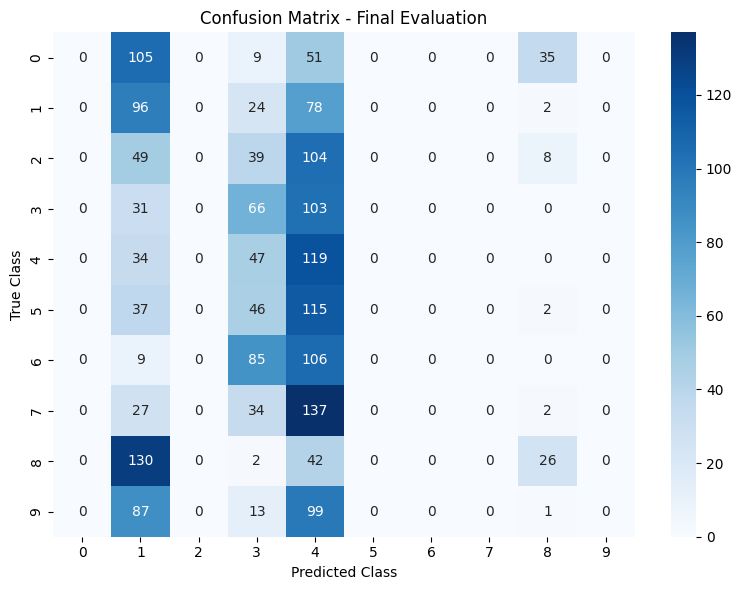

In [5]:
# Metrics and plots
from metrics import compute_continual_metrics, print_continual_summary, plot_confusion_matrix, plot_metrics_over_time, get_moe_utilization

print('=' * 80)
print('CONTINUAL LEARNING EVALUATION METRICS')
print('=' * 80)

# Print basic summary
print_continual_summary(test_history)

# Compute and plot continual metrics
metrics_dict = compute_continual_metrics(test_history)
plot_metrics_over_time(test_history)

# Confusion matrix (if available in final test)
final_test_result = test_history[-1] if test_history else {}
confusion_mat = final_test_result.get('overall', {}).get('confusion_matrix', {})
plot_confusion_matrix(confusion_mat)

# If this is an MoE model, show per-layer expert utilization (if available)
if is_model_moe:
    util = get_moe_utilization(model)
    if util:
        print('\nMoE utilization (per-layer):')
        for layer in util:
            fracs = layer.get('fraction', [])
            print(f"  Layer idx={layer['layer_index']} | samples={layer['samples']} | fractions={['{:.3f}'.format(x) for x in fracs]}")
    else:
        print('\nNo MoE utilization stats available (ensure model was evaluated in test mode)')


## Additional testings

In [6]:
# --- Reference / joint baselines (IM / FWT) ---------------------------------
# Runs only when COMPUTE_REFERENCE_BASELINES is True. Trains a fresh single-pass
# model per class (matches the continual single-pass behaviour) and exposes
# per-class joint/reference accuracies used to compute IM and FWT.
if COMPUTE_REFERENCE_BASELINES:
    print("\nComputing per-class reference baselines (fresh model per class, single pass)...")
    gen_device = getattr(device, 'type', 'cpu')
    gen = torch.Generator(device=gen_device)

    per_class_acc = {}

    for cls in all_classes:
        indices = class_to_indices_train.get(cls, [])
        if not indices:
            per_class_acc[cls] = np.nan
            continue

        # Subset the training dataset to this class only
        class_train_subset = torch.utils.data.Subset(dataset_train, indices)
        class_train_loader = torch.utils.data.DataLoader(
            class_train_subset, batch_size=REFERENCE_BATCH_SIZE, shuffle=True,
            num_workers=0, generator=gen)

        # Fresh convnext reference model for this class (single-pass)
        ref_model_c = torchvision.models.convnext_tiny(pretrained=False, num_classes=len(all_classes))
        ref_model_c.to(device)
        ref_loss = nn.CrossEntropyLoss()
        ref_optimizer = torch.optim.SGD(ref_model_c.parameters(), lr=1e-3)

        # Single pass over the class training data
        ref_model_c.train()
        epoch_loss = 0.0
        if len(class_train_loader) == 0:
            per_class_acc[cls] = np.nan
            continue
        for X, y in class_train_loader:
            X, y = X.to(device), y.to(device)
            pred = ref_model_c(X)
            loss = ref_loss(pred, y)
            loss.backward()
            ref_optimizer.step()
            ref_optimizer.zero_grad()
            epoch_loss += loss.item()

        print(f"  Trained ref model for class {cls} (single pass), avg loss: {epoch_loss/len(class_train_loader):.4f}")

        # Evaluate this fresh model on the test split of the same class
        test_indices = class_to_indices_test.get(cls, [])
        if not test_indices:
            per_class_acc[cls] = np.nan
            continue

        class_test_subset = torch.utils.data.Subset(dataset_test, test_indices)
        class_test_loader = torch.utils.data.DataLoader(
            class_test_subset, batch_size=REFERENCE_BATCH_SIZE, shuffle=False,
            num_workers=0, generator=gen)

        ref_model_c.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in class_test_loader:
                X, y = X.to(device), y.to(device)
                preds = ref_model_c(X)
                pred_labels = preds.argmax(1)
                correct += (pred_labels == y).sum().item()
                total += y.size(0)
        per_class_acc[cls] = 100.0 * correct / max(1, total)

    # Expose per-class reference accuracies under the same name used downstream
    joint_per_class_acc = {cls: per_class_acc.get(cls, np.nan) for cls in all_classes}

    # Save per-class reference results
    timestr_ref = time.strftime("%Y%m%d-%H%M%S")
    ref_save_path = os.path.join(os.getcwd(), 'results', timestr_ref + '_per_class_reference.pth')
    torch.save({'joint_per_class_acc': joint_per_class_acc}, ref_save_path)
    print(f"Saved per-class reference baselines to {ref_save_path} (model weights not saved)")

    # Build a reference R (single final-row) and re-run metric computation so
    # IM/FWT are available in the main metrics dict.
    R_ref = np.array([[joint_per_class_acc.get(c, np.nan) for c in all_classes]])

    # Recompute continual metrics using the reference (this will populate 'im' and 'fwt')
    metrics_dict = compute_continual_metrics(test_history, reference={'R': R_ref})
    print(f"Intransigence (IM): {metrics_dict.get('im')}")
    print(f"Forward Transfer (FWT): {metrics_dict.get('fwt')}")

else:
    print("\nIM / FWT disabled — set COMPUTE_REFERENCE_BASELINES = True at the top of the notebook to enable")


IM / FWT disabled — set COMPUTE_REFERENCE_BASELINES = True at the top of the notebook to enable
